### **Week 2 - Data Cleaning, Preprocessing, and Feature Engineering**

Goal: Convert raw food interaction data into clean train/test data and engineered food metadata features.

<table style="width: 100%; border-collapse: collapse; font-family: sans-serif; font-size: 14px;">
  <thead>
    <tr style="background-color: #5b9bd5; color: white;">
      <th style="border: 1px solid #7f7f7f; padding: 10px; text-align: left; font-weight: bold; width: 25%;">Task</th>
      <th style="border: 1px solid #7f7f7f; padding: 10px; text-align: left; font-weight: bold; width: 50%;">Details</th>
      <th style="border: 1px solid #7f7f7f; padding: 10px; text-align: left; font-weight: bold; width: 25%;">Deliverable</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top; font-weight: bold;">Clean Interaction Data</td>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top;">Remove duplicate interactions, handle missing ratings, normalize ratings, filter sparse users/items, create implicit feedback label.</td>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top;">03_data_preprocessing.ipynb</td>
    </tr>
    <tr>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top; font-weight: bold;">Food Metadata Table</td>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top;">Prepare item_id, recipe name, ingredients, calories, protein, fat, carbs, category, preparation time, and review text.</td>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top;">food_metadata_clean.csv</td>
    </tr>
    <tr>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top; font-weight: bold;">Nutrition Features</td>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top;">Create calorie_level, protein_level, fat_level, ingredient_count, health_score, and preparation_complexity.</td>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top;">04_feature_engineering.ipynb</td>
    </tr>
    <tr>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top; font-weight: bold;">Train-Test Split</td>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top;">Create user-wise 80:20 split for top-K recommendation evaluation.</td>
      <td style="border: 1px solid #7f7f7f; padding: 10px; vertical-align: top;">train_interactions.csv,<br>test_interactions.csv</td>
    </tr>
  </tbody>
</table>

In [1]:
import  pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("food_metadata_clean.csv")

In [3]:
df.columns=df.columns.str.strip().str.lower()

In [4]:
print(df.shape)

(522517, 10)


In [5]:
print(df.head)

<bound method NDFrame.head of         item_id                                       recipe_name  \
0            38                 Low-Fat Berry Blue Frozen Dessert   
1            39                                           Biryani   
2            40                                     Best Lemonade   
3            41                    Carina's Tofu-Vegetable Kebabs   
4            42                                      Cabbage Soup   
...         ...                                               ...   
522512   541379                    Meg's Fresh Ginger Gingerbread   
522513   541380  Roast Prime Rib au Poivre with Mixed Peppercorns   
522514   541381                             Kirshwasser Ice Cream   
522515   541382          Quick & Easy Asian Cucumber Salmon Rolls   
522516   541383                           Spicy Baked Scotch Eggs   

                                              ingredients  calories  protein  \
0       c("blueberries", "granulated sugar", "vanilla ...    

In [6]:
numeric_cols = ['calories', 'protein', 'fat', 'carbs', 'prep_time']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

In [7]:
def calorie_level(x):
    if x < 200:
        return "Low"
    elif x < 500:
        return "Medium"
    else:
        return "High"

df['calorie_level'] = df['calories'].apply(calorie_level)

In [8]:
df['protein_level'] = df['protein'].apply(
    lambda x: "High" if x > 20 else "Medium" if x > 10 else "Low"
)

In [9]:
df['fat_level'] = df['fat'].apply(
    lambda x: "High" if x > 20 else "Medium" if x > 10 else "Low"
)

In [10]:
df['ingredient_count'] = df['ingredients'].apply(
    lambda x: len(str(x).split(","))
)

In [11]:
df['health_score'] = (
    df['protein'] * 2 - df['fat'] - df['calories'] * 0.01
)

In [12]:
df['preparation_complexity'] = df['prep_time'].apply(
    lambda x: "Easy" if x < 30 else "Medium" if x < 60 else "Hard"
)

### **Visualizing Engineered Features**

Here we visualize the distribution of each engineered feature.

C:\Users\ishan shastri\AppData\Local\Temp\ipykernel_22656\2974625744.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='calorie_level', data=df, order=["Low", "Medium", "High"], palette="Blues_d")


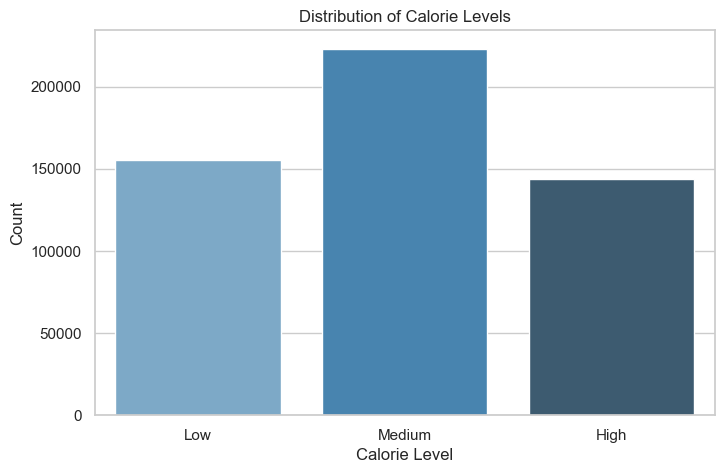

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("output_of_the feature_engineering", exist_ok=True)
os.makedirs("output", exist_ok=True)

# 1. Calorie Level Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='calorie_level', data=df, order=["Low", "Medium", "High"], palette="Blues_d")
plt.title("Distribution of Calorie Levels")
plt.xlabel("Calorie Level")
plt.ylabel("Count")
plt.savefig("output_of_the feature_engineering/calorie_level_distribution.png", dpi=150, bbox_inches='tight')
plt.savefig("output/calorie_level_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ishan shastri\AppData\Local\Temp\ipykernel_22656\2799164640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protein_level', data=df, order=["Low", "Medium", "High"], palette="Greens_d")


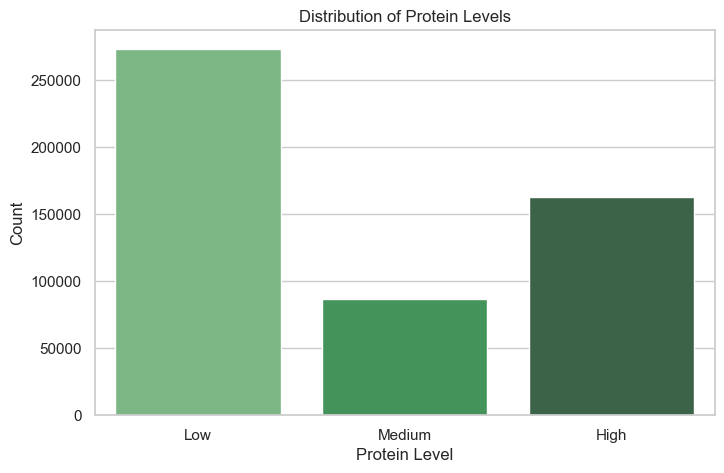

In [14]:
# 2. Protein Level Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='protein_level', data=df, order=["Low", "Medium", "High"], palette="Greens_d")
plt.title("Distribution of Protein Levels")
plt.xlabel("Protein Level")
plt.ylabel("Count")
plt.savefig("output_of_the feature_engineering/protein_level_distribution.png", dpi=150, bbox_inches='tight')
plt.savefig("output/protein_level_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ishan shastri\AppData\Local\Temp\ipykernel_22656\4072002139.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fat_level', data=df, order=["Low", "Medium", "High"], palette="Oranges_d")


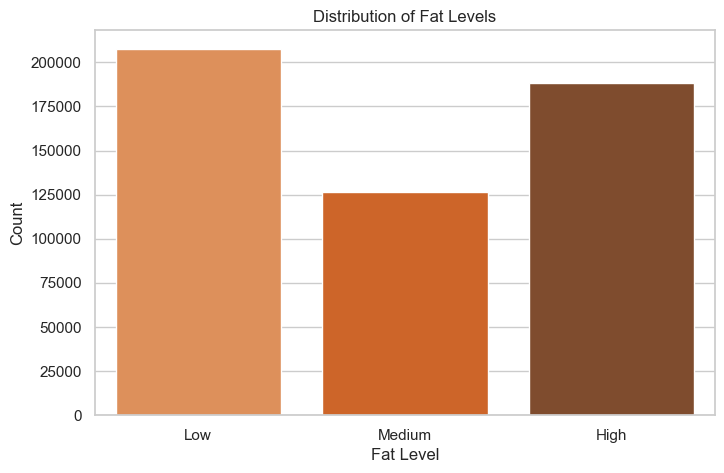

In [15]:
# 3. Fat Level Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='fat_level', data=df, order=["Low", "Medium", "High"], palette="Oranges_d")
plt.title("Distribution of Fat Levels")
plt.xlabel("Fat Level")
plt.ylabel("Count")
plt.savefig("output_of_the feature_engineering/fat_level_distribution.png", dpi=150, bbox_inches='tight')
plt.savefig("output/fat_level_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

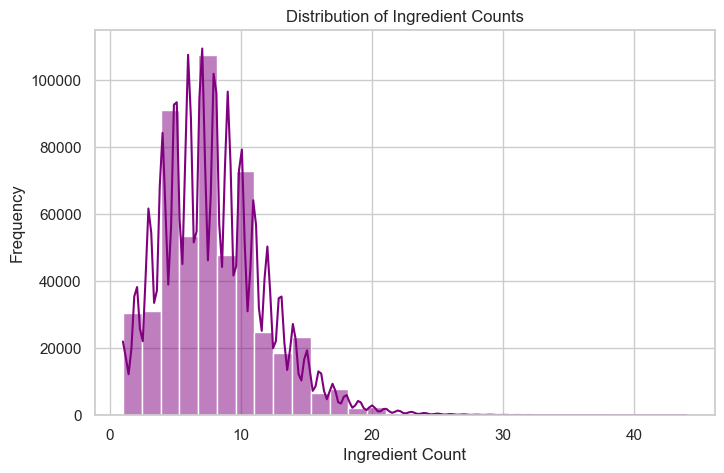

In [16]:
# 4. Ingredient Count Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['ingredient_count'], bins=30, kde=True, color="purple")
plt.title("Distribution of Ingredient Counts")
plt.xlabel("Ingredient Count")
plt.ylabel("Frequency")
plt.savefig("output_of_the feature_engineering/ingredient_count_distribution.png", dpi=150, bbox_inches='tight')
plt.savefig("output/ingredient_count_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

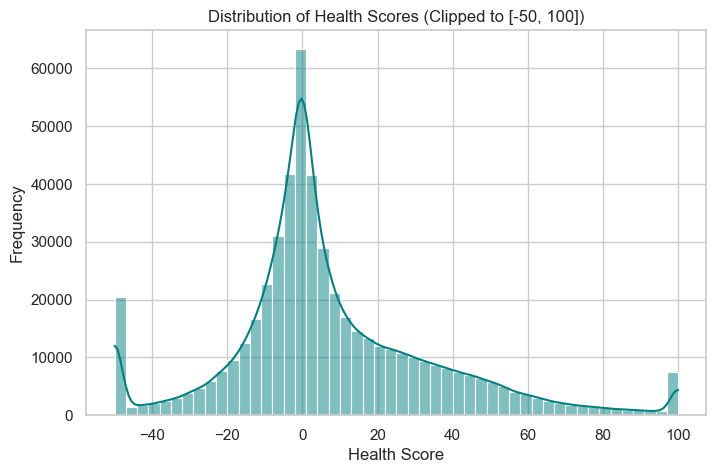

In [17]:
# 5. Health Score Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['health_score'].clip(-50, 100), bins=50, kde=True, color="teal")
plt.title("Distribution of Health Scores (Clipped to [-50, 100])")
plt.xlabel("Health Score")
plt.ylabel("Frequency")
plt.savefig("output_of_the feature_engineering/health_score_distribution.png", dpi=150, bbox_inches='tight')
plt.savefig("output/health_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ishan shastri\AppData\Local\Temp\ipykernel_22656\2567598157.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='preparation_complexity', data=df, order=["Easy", "Medium", "Hard"], palette="Purples_d")


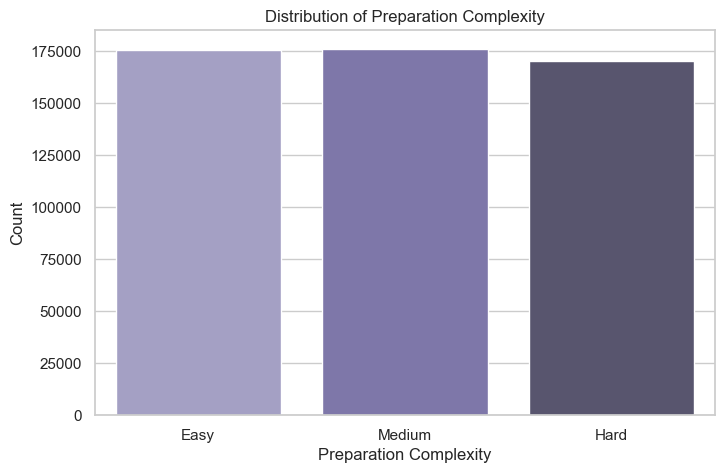

In [18]:
# 6. Preparation Complexity Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='preparation_complexity', data=df, order=["Easy", "Medium", "Hard"], palette="Purples_d")
plt.title("Distribution of Preparation Complexity")
plt.xlabel("Preparation Complexity")
plt.ylabel("Count")
plt.savefig("output_of_the feature_engineering/preparation_complexity_distribution.png", dpi=150, bbox_inches='tight')
plt.savefig("output/preparation_complexity_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [19]:
df[['calories','calorie_level',
    'protein','protein_level',
    'fat','fat_level',
    'ingredient_count',
    'health_score',
    'prep_time','preparation_complexity']].head()

,calories,calorie_level,protein,protein_level,fat,fat_level,ingredient_count,health_score,prep_time,preparation_complexity
0,170.9,Low,3.2,Low,2.5,Low,4,2.191,1485.0,Hard
1,1110.7,High,63.4,High,58.8,High,25,56.893,265.0,Hard
2,311.1,Medium,0.3,Low,0.2,Low,7,-2.711,35.0,Medium
3,536.1,High,29.3,High,24.0,High,14,29.239,1460.0,Hard
4,103.6,Low,4.3,Low,0.4,Low,5,7.164,50.0,Medium


In [20]:
df.to_csv("food_features_engineered.csv", index=False)

print("✅ Feature Engineering Done")

✅ Feature Engineering Done
